# pytorch 加载数据

## 导入必要库
这里我们导入了torch and torchaudio。

In [1]:
import torch 
import torchaudio

## 访问数据集中的数据

In [2]:
torchaudio.datasets.YESNO(
    root='./dataset',
    url='http://www.openslr.org/resources/1/waves_yesno.tar.gz',
    folder_in_archive='waves_yesno',
    download=True
)

100%|██████████| 4.49M/4.49M [00:01<00:00, 3.50MB/s]


下载下来的每一个条码都是一个元组，形式为：（波形，采样率，标签）。

In [3]:
yesno_data = torchaudio.datasets.YESNO( './dataset', download = True)

n = 3

waveform, sample_rate, labels = yesno_data[n]

print("Waveform:{} \nSample rate: {} \nLabels: {}".format(waveform, sample_rate, labels))

Waveform:tensor([[ 3.0518e-05,  6.1035e-05,  3.0518e-05,  ..., -1.8311e-04,
          4.2725e-04,  6.7139e-04]]) 
Sample rate: 8000 
Labels: [0, 0, 1, 0, 0, 0, 1, 0]


再实践中，我们需要将数据划分为训练集和测试集，已测试模型的泛化性能。

## 加载数据
DataLoader将数据集和采样器组合在一起，返回一个可迭代对象。

In [4]:
data_loader = torch.utils.data.DataLoader(yesno_data, batch_size = 1, shuffle = True)

## 遍历数据
我们现在的数据将使用data_loader进行迭代。训练模型的时候，这是必须的。 每一个数据条目都被转化为一个张量。

In [5]:
for data in data_loader:
    print('data:', data)
    print("waveform:{}\nsample rate:{}\nlabels:{}".format(data[0], data[1], data[2]))
    break

data: [tensor([[[3.0518e-05, 6.1035e-05, 3.0518e-05,  ..., 2.1362e-03,
          2.0142e-03, 2.2278e-03]]]), tensor([8000]), [tensor([1]), tensor([0]), tensor([0]), tensor([0]), tensor([0]), tensor([0]), tensor([1]), tensor([1])]]
waveform:tensor([[[3.0518e-05, 6.1035e-05, 3.0518e-05,  ..., 2.1362e-03,
          2.0142e-03, 2.2278e-03]]])
sample rate:tensor([8000])
labels:[tensor([1]), tensor([0]), tensor([0]), tensor([0]), tensor([0]), tensor([0]), tensor([1]), tensor([1])]


## 对数据进行可视化
进一步我们可以使用matplotlib对数据进行可视化。

[[3.0517578e-05 6.1035156e-05 3.0517578e-05 ... 2.1362305e-03
  2.0141602e-03 2.2277832e-03]]


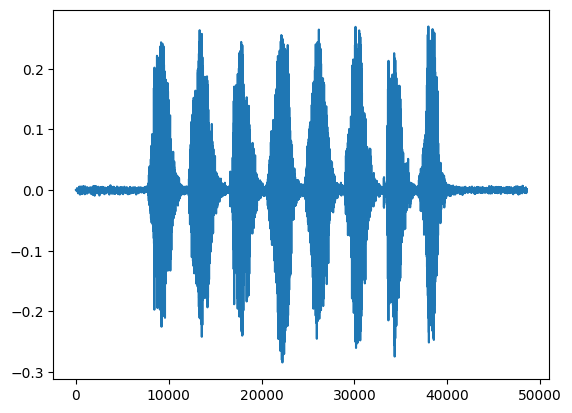

In [6]:
import matplotlib.pyplot as plt

print(data[0][0].numpy())

plt.figure()
plt.plot(waveform.t().numpy())